In [ ]:
### TASK-ONLY TDANN perform PLSR with brain

### img fea extraction

In [1]:
import os
from os.path import join as pjoin
basedir = r'F:\visual_project\TDANN'
code_path = pjoin(basedir, r'TDANN-main')
positions_dir = pjoin(basedir, r'tdann_data/tdann/positions/simclr_spatial_resnet18_fuzzy_swappedon_SineGrating2019_lw0/resnet18_retinotopic_init_fuzzy_swappedon_SineGrating2019_NBVER2')
weights_path = pjoin(basedir, r'tdann_data/tdann/checkpoints/simclr_spatial_resnet18_swappedon_SineGrating2019_isoswap_3_lw0_checkpoints', f'model_final_checkpoint_phase199.torch')
# image_path = pjoin(basedir, r'property_analysis/code/cnn-som/TDANN', r'tdann_data/image', f'test_img.jpg')

import sys
sys.path.append(code_path)
os.chdir(pjoin(code_path, 'demo'))

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.autograd import Variable as V
from torchvision import transforms as trn
from src.positions import NetworkPositions
from src.model import load_model_from_checkpoint, LAYERS
from src.data import load_image, create_dataloader
from src.features import FeatureExtractor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# DEVICE = "cpu"

# load positions from each model layer
network_positions = NetworkPositions.load_from_dir(positions_dir)

# load model from checkpoint and send to appropriate device
model = load_model_from_checkpoint(weights_path)
model = model.to(DEVICE)


img_set_dir = pjoin(r'F:\visual_project\THINGS_project\THINGS_stimuli\THINGS\Images')
img_partitions = os.listdir(img_set_dir)

# Create the saving directory if not existing
save_dir = pjoin(r'F:\visual_project\THINGS_project\THINGS_stimuli\THINGS\derivatives\dnn_feature_maps\taskonly')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# image processing
centre_crop = trn.Compose([
    trn.Resize((224,224)),
    trn.ToTensor(),
    trn.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

feat_list = ['layer1.0','layer1.1','layer2.0','layer2.1','layer3.0','layer3.1','layer4.0','layer4.1']

# ['object_images_D-K', 'object_images_L-Q', 'password.txt', 'object_images_T-Z', 'object_images_A-C', 'object_images_R-S']


for p in img_partitions:
    # if p=='object_images_D-K' or p=='object_images_L-Q' or p=='password.txt':
    #     # break # 跳出本层循环
    #     continue # 跳出本次循环 
    part_dir = pjoin(img_set_dir, p) # imageset A-Z
    img_partitions_ = os.listdir(part_dir)
    for pp in img_partitions_:
        part_dir_ = pjoin(part_dir, pp) # image category aardvark to zucchini
        image_list = []
        for root, dirs, files in os.walk(part_dir_):
            for file in files:
                if file.endswith(".jpg") or file.endswith(".JPEG"):
                    image_list.append(pjoin(root,file))
        image_list.sort()
        # Extract and save the feature maps
        feats_ = {}
        for i, image in enumerate(image_list):
            # img = Image.open(image).convert('RGB')
            # input_img = V(centre_crop(img).unsqueeze(0))
            # if torch.cuda.is_available():
            #     input_img=input_img.cuda()
            # create a dataloader to serve the single image we're pointing to
            dataloader = create_dataloader(load_image(image))
            # extract features for all layers, also storing the images and labels
            extractor = FeatureExtractor(dataloader, n_batches=1, verbose=True)
            features, inputs, labels = extractor.extract_features(model, LAYERS, return_inputs_and_labels=True)

            feats = {}
            for ly in feat_list:
                feats[ly] = features[ly].flatten()
            feats_[i] = feats
        feat_avg = {}
        for ly in feat_list:
            tmp = []
            for ii, image in enumerate(image_list):
                tmp.append(feats_[ii][ly].squeeze())
            tmp_ = np.array(tmp)
            tmp_avg = np.mean(tmp_,0)
            feat_avg[ly] = tmp_avg
        
        np.save(os.path.join(save_dir, pp), feat_avg)

d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
F:\visual_project\TDANN\TDANN-main\demo\src\model.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functio

KeyboardInterrupt: 

### PLSR

In [9]:
# trial6 PLSR between model and brain
# so could get bra clu voxel wei to each mdl unit

# prepare brain data
import os
import h5py
import numpy as np
import scipy.io as scio
import matplotlib.pyplot as plt
from os.path import join as pjoin
# from nilearn.masking import apply_mask, unmask

basedir = r'F:\visual_project\THINGS_project'
sub = '03'

outdir_ = pjoin(basedir, r'animacy_analysis\derivatives\2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()

f_dir = pjoin(basedir, r'animacy_analysis\derivatives\3_pro_representation\linear model','sub-'+sub)
# p value of training set
adjp_f = pjoin(f_dir, 'prop_pcs', f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

cor_f = pjoin(f_dir, 'prop_pcs', f'model_test_result.mat')
corf = h5py.File(cor_f)
print(corf.keys())
cor_ = corf['R']
cor = np.squeeze(cor_) # r value

# # prop pcs selection of each voxel in each ROI
# wei_f = pjoin(f_dir, 'prop_pcs','encoding_training_result.mat')
# weif = h5py.File(wei_f) # encoding weight
# print(weif.keys())
# wei_ = weif['thetaFinal']
# wei = np.squeeze(wei_)
# print(wei.shape) #(V,5)

mkb = [] # sig mask of brain
for j in range(len(adj_p)):
    if adj_p[j]<0.05 and cor[j]>0.05:
        mkb.append(j)
# wei_s = wei[mkb,:3]

# prop selection in each cluster

yhat_ = np.load(pjoin(f_dir,'prop_pcs','volume_pc_clu_label3.npz'))
yhat = yhat_['label']

idxb_clu1 = [] # idx of brain for each clu
idxb_clu2 = []
idxb_clu3 = []

for i in range(len(mkb)):
    if yhat[i] == 0:
        idxb_clu1.append(i)
    if yhat[i] == 1:
        idxb_clu2.append(i)
    if yhat[i] == 2:
        idxb_clu3.append(i)

# weib_clu1 = wei_s[idxb_clu1] # (1904,3)
# weib_clu2 = wei_s[idxb_clu2] # (1055,3)
# weib_clu3 = wei_s[idxb_clu3] # (1551,3)

# prepare brain activation
betas_csv_dir = pjoin(basedir, r'THINGS_fMRI/betas_csv')
betas_concept_ = scio.loadmat(pjoin(betas_csv_dir, f'sub-{sub}_betas_concept.mat'))
betas_concept =  betas_concept_['data'] # (V,720)
print(betas_concept.shape)
                              
# actb_clu1 = betas_concept[mkb][idxb_clu1].T
# # print(act_clu1.shape) # (720,1904)
# actb_clu2 = betas_concept[mkb][idxb_clu2].T
# # print(act_clu2.shape) # (720,1055)
# actb_clu3 = betas_concept[mkb][idxb_clu3].T
# # print(act_clu3.shape) # # (720,1551)
# # act_clu = [act_clu1,act_clu2,act_clu3]

# prepare model activation
lys = feat_list
img_fea_dir = pjoin(basedir, r'THINGS_stimuli\THINGS\derivatives\dnn_feature_maps\taskonly')
img_partitions = os.listdir(img_fea_dir)
img_partitions.sort()
img_fea = []
for p in img_partitions:
    part_dir = os.path.join(img_fea_dir, p)
    fea = np.load(part_dir,allow_pickle=True)
    fea_ = fea.tolist()
    img_fea.append(fea_[lys[7]].flatten())
#     img_fea.append(fea_['fc8'])
img_model_ = np.array(img_fea)
#     img_alex = img_fea_[obj12_df.index]
img_model_sub = img_model_[ind_1854to720]
print(img_model_sub.shape) #(720,25088)
img_model_sub = img_model_sub
# actm_clu1 = img_model_sub[mk][idx_clu1].T # model activation for each clu
# actm_clu2 = img_model_sub[mk][idx_clu2].T
# actm_clu3 = img_model_sub[mk][idx_clu3].T

<KeysViewHDF5 ['adj_p', 'mask', 'trial_sum_all']>
<KeysViewHDF5 ['R', 'X_pred', 'betas_test']>
(720, 189164)
(720, 25088)


In [10]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

print(betas_concept.T[mkb].shape) #(4510, 720)
print(img_model_sub.shape) #(25088, 720)
x = betas_concept.T[mkb].T
y = img_model_sub
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1, random_state=97)


(2299, 720)
(720, 25088)


0.6132083325573524 0.10594628223237894
0.7810556234533348 0.2678300063982024


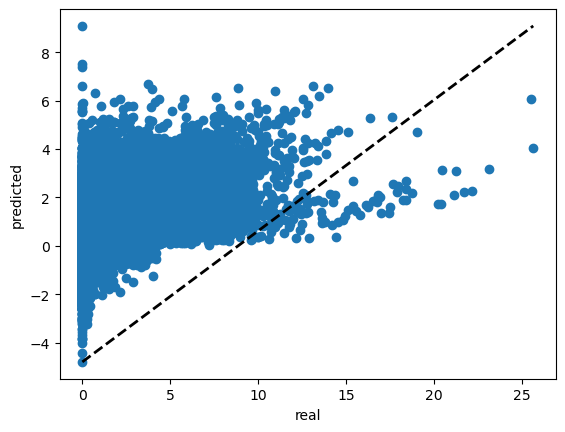

In [11]:
# plsregression
plsr = PLSRegression(n_components=50)
plsr.fit(x_train,y_train)

y_pred = plsr.predict(x_test)

# score = plsr.score(x_test,y_test) # score is 1, best
# print(score)
cor = []
for i in range(y_test.shape[0]):
    cor_ = pearsonr(y_pred[i],y_test[i])
    cor.append(cor_[0])
cor_mean = np.mean(np.array(cor))
cor_std = np.std(np.array(cor))
print(cor_mean, cor_std)
print(np.max(cor),np.min(cor))

plt.scatter(y_test,y_pred)
plt.xlabel('real')
plt.ylabel('predicted')
plt.plot([y_test.min(),y_test.max()],[y_pred.min(),y_pred.max()],'k--',lw=2)
plt.show()
